⚠️ Colonne 'step' non trouvée. Utilisation de valeurs par défaut (0).
🔄 Application de SMOTE pour équilibrer les classes...


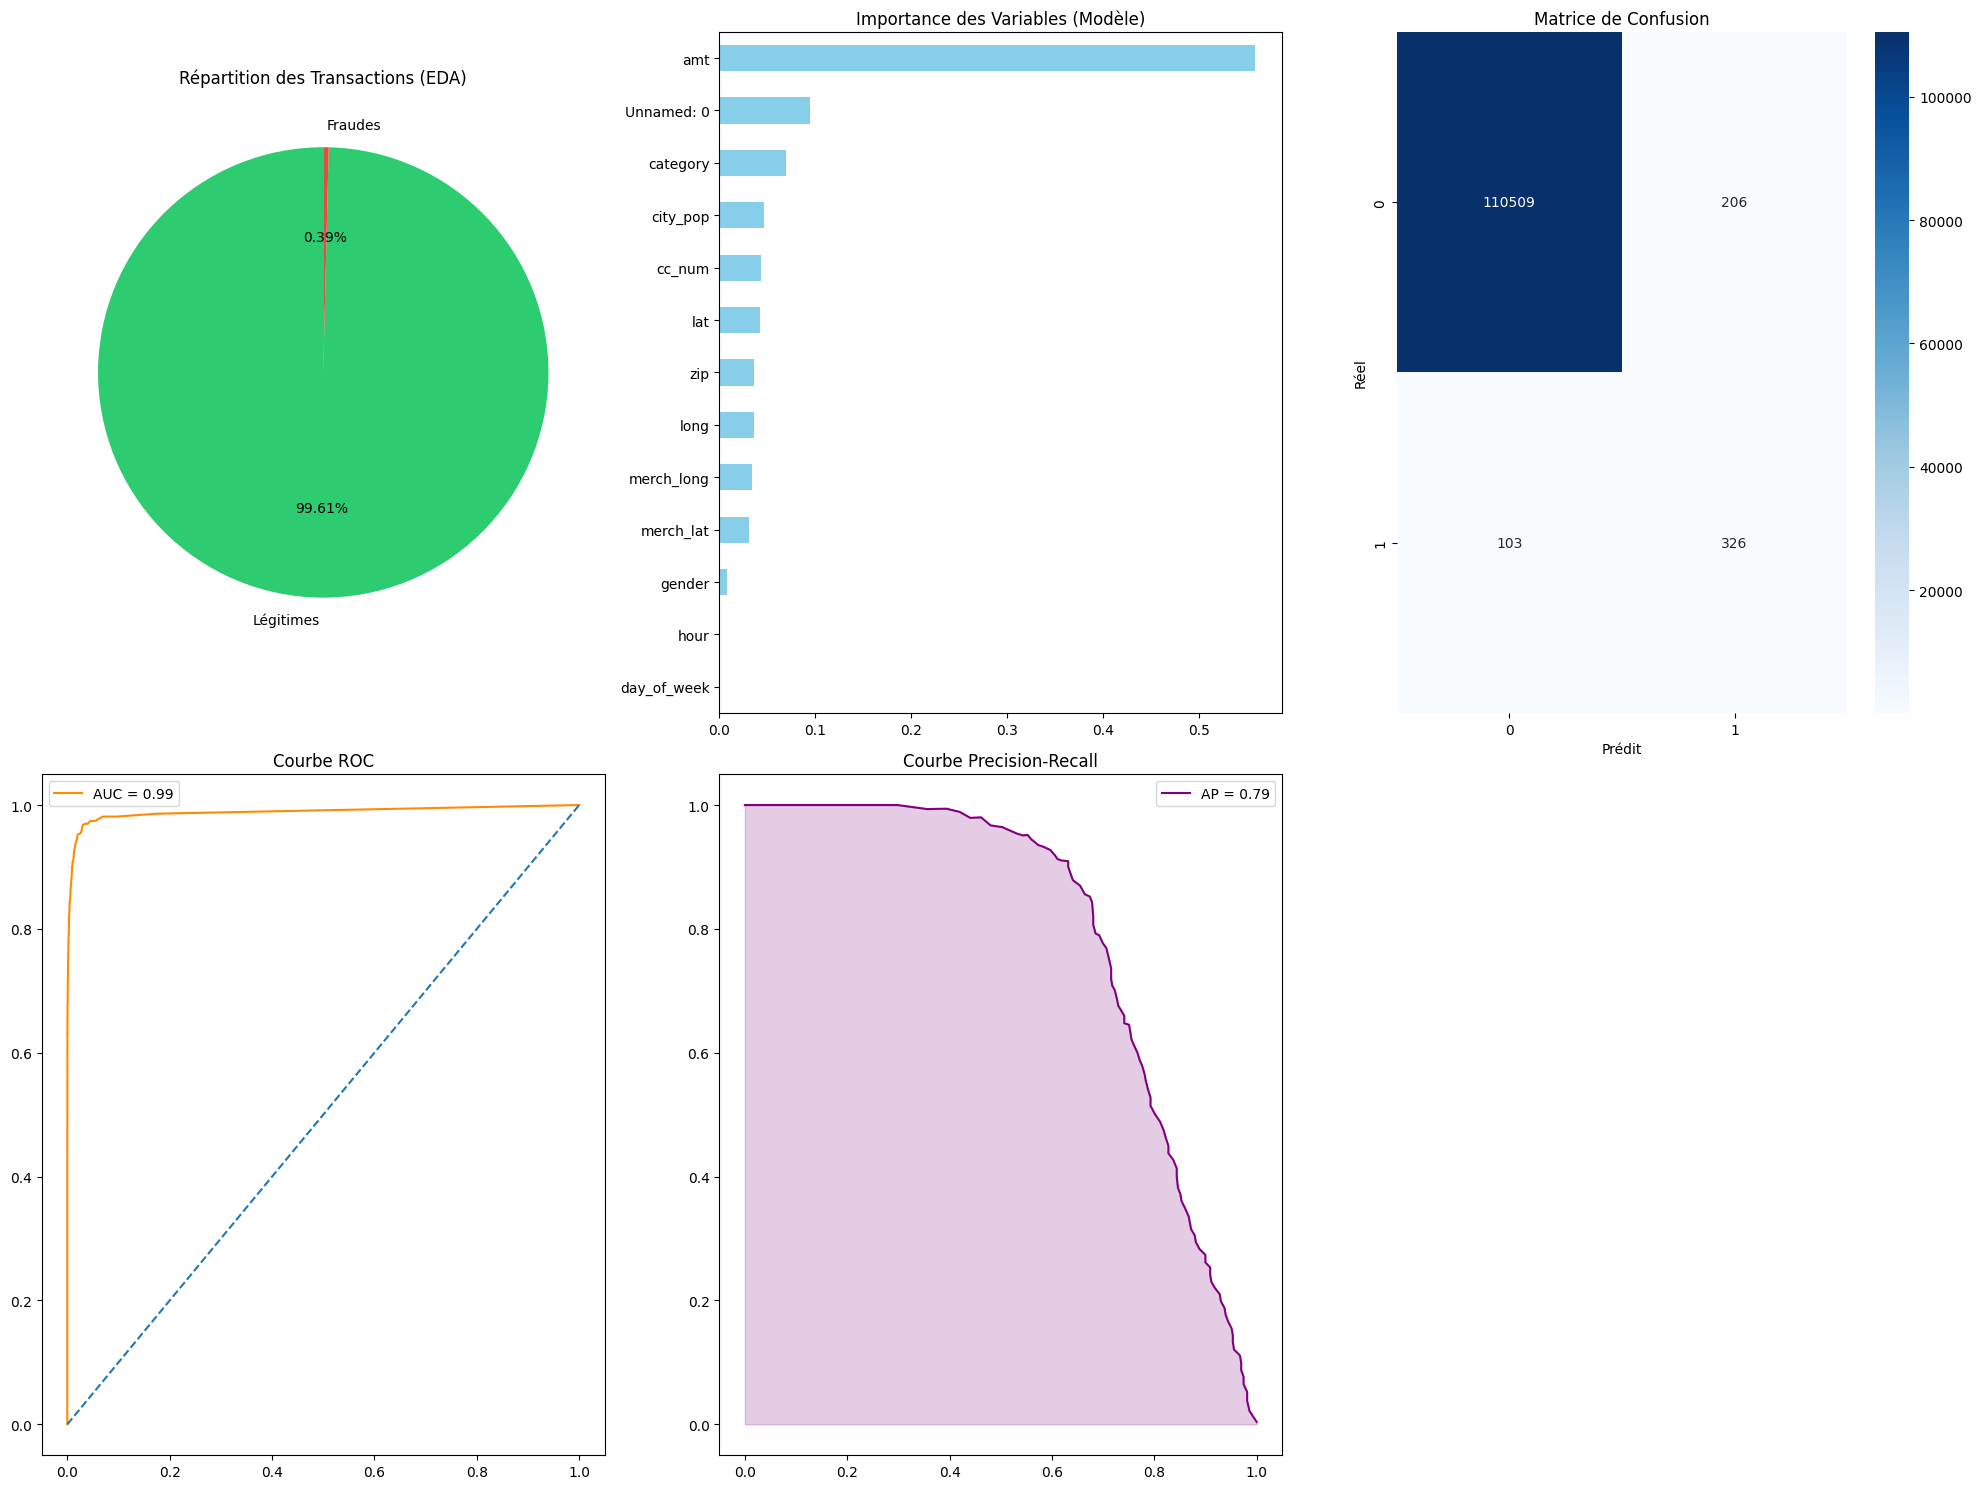


--- RAPPORT DE PERFORMANCE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.61      0.76      0.68       429

    accuracy                           1.00    111144
   macro avg       0.81      0.88      0.84    111144
weighted avg       1.00      1.00      1.00    111144



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, 
                             auc, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE 
import warnings

warnings.filterwarnings('ignore')

# 1. Chargement du dataset
path = '/mnt/c/Users/david/Desktop/AIA 2025/BLOC_3_AUTOMATIC_FRAUD_DETECTION/projet_fraud_detection/src/data/fraud_test.csv'
df = pd.read_csv(path)

# --- CORRECTION SÉCURITÉ : VÉRIFICATION DE LA COLONNE STEP ---
# On cherche 'step' sans tenir compte de la casse pour éviter le KeyError
col_step = next((c for c in df.columns if c.lower() == 'step'), None)

if col_step:
    df['hour'] = df[col_step] % 24
    df['day_of_week'] = (df[col_step] // 24) % 7
    print(f"✅ Variables temporelles créées depuis la colonne '{col_step}'")
else:
    print(f"⚠️ Colonne 'step' non trouvée. Utilisation de valeurs par défaut (0).")
    df['hour'] = 0
    df['day_of_week'] = 0

# 2. Nettoyage et Encodage (Paramètres alignés sur testmodel.ipynb)
# On ajoute 'trans_date_trans_time' à la suppression pour éviter l'erreur de conversion string to float
cols_to_drop = [col_step, 'customer', 'age', 'zipcodeOri', 'zipMerchant', 'merchant', 'trans_date_trans_time', 'unix_time']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Encodage des variables catégorielles (LabelEncoder comme demandé)
le = LabelEncoder()
for col in ['type', 'gender', 'category']:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 3. Préparation Numérique pour SMOTE
# On ne garde que le numérique pour éviter les crashs de SMOTE
X = df_clean.drop('is_fraud', axis=1).select_dtypes(include=[np.number])
y = df_clean['is_fraud']

# Split Stratifié (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Équilibrage SMOTE
print("🔄 Application de SMOTE pour équilibrer les classes...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 4. Modèle RandomForest (Paramètres de testmodel : n_estimators=100)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Prédictions
y_pred = rf.predict(X_test)
y_score = rf.predict_proba(X_test)[:, 1]

# --- EDA COMPLET ET VISUALISATIONS ---
plt.figure(figsize=(20, 15))

# A. Camembert : Répartition Fraudes (startangle=90)
plt.subplot(2, 3, 1)
counts = y.value_counts()
plt.pie(counts, labels=['Légitimes', 'Fraudes'], autopct='%1.2f%%', startangle=90, 
        colors=['#2ecc71', '#e74c3c'], explode=(0, 0))
plt.title("Répartition des Transactions (EDA)")

# B. Importance des Features
plt.subplot(2, 3, 2)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_importances.plot(kind='barh', color='skyblue')
plt.title("Importance des Variables (Modèle)")

# C. Matrice de Confusion
plt.subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")

# D. Courbe ROC
plt.subplot(2, 3, 4)
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("Courbe ROC")
plt.legend()

# E. Courbe Precision-Recall
plt.subplot(2, 3, 5)
precision, recall, _ = precision_recall_curve(y_test, y_score)
plt.plot(recall, precision, color='purple', label=f'AP = {average_precision_score(y_test, y_score):.2f}')
plt.fill_between(recall, precision, alpha=0.2, color='purple')
plt.title("Courbe Precision-Recall")
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- RAPPORT DE PERFORMANCE ---")
print(classification_report(y_test, y_pred))